# CityScore — a livability index for Prince William County, VA

Seventeen ZIP areas scored 0–100 from six indicators: crime, income, education,
housing, unemployment and population density.

The interesting part of a composite index is never the arithmetic — it is the two
choices the arithmetic hides. **Which direction is each indicator "good" in**, and
**how much does each one count**. This notebook makes both explicit, then measures
how much the ranking actually depends on them.

It also documents a problem with the original crime input, which turned out to be
a truncated export. That is dealt with first, because crime carries the largest
weight in the composite.

**Run order:** `python build_data.py` refreshes everything in `data/` from its
public source. This notebook then runs top to bottom against `data/` alone.

## 0. Setup

In [1]:
import json
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd()
DATA, OUT, IMG = HERE / "data", HERE / "outputs", HERE / "images"
OUT.mkdir(exist_ok=True); IMG.mkdir(exist_ok=True)

# One look for every figure, so nothing arrives from a different rendering engine.
INK, MUTED, RULE = "#1E1E1B", "#6B6862", "#D9D4C7"
ACCENT, WARN, COOL = "#1B4D8F", "#B04A2F", "#6E9DC9"
plt.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 200, "savefig.bbox": "tight",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "font.family": "DejaVu Sans", "font.size": 9,
    "axes.edgecolor": RULE, "axes.linewidth": 0.8, "axes.labelcolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "axes.titlelocation": "left", "axes.titlepad": 12,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelcolor": INK, "ytick.labelcolor": INK,
    "grid.color": RULE, "grid.linewidth": 0.6, "legend.frameon": False,
})

def save(fig, name):
    fig.savefig(IMG / f"{name}.png", facecolor="white")
    print(f"wrote images/{name}.png")

ind = pd.read_csv(DATA / "indicators.csv", dtype={"ZIP": str})
shapes = gpd.read_file(DATA / "zcta_boundaries.geojson").astype({"ZIP": str})
print(f"{len(ind)} ZIP areas, {len(shapes)} polygons")
ind.head(3)

17 ZIP areas, 17 polygons


,ZIP,Income,Population,LandArea,Density,Education,Housing,Unemployment,CrimeRateOriginal,Incidents,CrimeRate,OutsideJurisdiction,JurisdictionNote
0,20109,88966.0,43849.0,23.83,1840.075535,0.351,411700.0,0.041,65.0,4203,95.851673,False,NaN
1,20110,120397.0,49120.0,9.89,4966.632963,0.335,445300.0,0.030,52.7,739,15.044788,True,"City of Manassas — independent city, own polic..."
2,20111,109785.0,38883.0,10.02,3880.538922,0.302,449400.0,0.042,45.5,843,21.680426,True,partly Manassas Park — independently policed


## 1. The crime input had to be rebuilt

The project originally read crime from `Crime Reports.csv`, a 16,000-row export
now kept in `archive/`. Three facts about that file, in the order they turned up:

1. It contains **exactly 16,000 rows**.
2. The county's feature service declares `maxRecordCount: 16000` — a single
   request cannot return more.
3. That service reports **23,914 incidents inside the same date window** the
   export covers.

So the export holds roughly two thirds of its own window and stops where the API
stopped, not where the data did. Nothing suggests the missing third is spread
evenly across ZIP codes, so a rate built from it is not a rate.

`build_data.py` pages past the cap and pulls all **25,829** incidents reported in
calendar 2025, then assigns each to a ZIP area by point-in-polygon against Census
ZCTA boundaries. The service publishes a `ZipCode` field, but it is null on every
public record, so the spatial join is the only route.

In [2]:
trunc = pd.read_csv("archive/crime_reports_truncated_export.csv", low_memory=False)
full = pd.read_csv(DATA / "crime_incidents_2025.csv", low_memory=False)

print(f"archived export        {len(trunc):>7,} rows   (service maxRecordCount = 16,000)")
print(f"complete 2025 pull     {len(full):>7,} rows")
print(f"share the export held  {16000 / 23914:>7.1%} of its own date window")

archived export         16,000 rows   (service maxRecordCount = 16,000)
complete 2025 pull      25,829 rows
share the export held    66.9% of its own date window


### What the difference does to the numbers

The original `Crime Rate(/1,000)` column is kept as `CrimeRateOriginal` so the two
can be compared directly. They are close to unrelated.

In [3]:
cmp = ind[["ZIP", "Population", "Incidents", "CrimeRate", "CrimeRateOriginal",
           "OutsideJurisdiction"]].copy()
cmp["RankDerived"] = cmp.CrimeRate.rank(ascending=False).astype(int)
cmp["RankOriginal"] = cmp.CrimeRateOriginal.rank(ascending=False).astype(int)
cmp["RankShift"] = (cmp.RankOriginal - cmp.RankDerived)

pearson = cmp.CrimeRate.corr(cmp.CrimeRateOriginal)
spearman = cmp.CrimeRate.corr(cmp.CrimeRateOriginal, method="spearman")
print(f"pearson  {pearson:+.3f}")
print(f"spearman {spearman:+.3f}   <- rank agreement is essentially nil")

cmp.to_csv(OUT / "crime_rate_comparison.csv", index=False)
cmp.sort_values("CrimeRate", ascending=False).round(1)

pearson  +0.292
spearman +0.115   <- rank agreement is essentially nil


,ZIP,Population,Incidents,CrimeRate,CrimeRateOriginal,OutsideJurisdiction,RankDerived,RankOriginal,RankShift
15,22192,60299.0,5843,96.9,23.2,False,1,6,5
0,20109,43849.0,4203,95.9,65.0,False,2,1,-1
14,22191,74189.0,4596,61.9,29.7,False,3,4,1
9,22025,18470.0,957,51.8,22.1,False,4,10,6
10,22026,20225.0,996,49.2,22.7,False,5,8,3
12,22134,7357.0,308,41.9,6.1,True,6,17,11
16,22193,83064.0,3278,39.5,27.3,False,7,5,-2
13,22172,10679.0,421,39.4,8.9,False,8,14,6
6,20155,37218.0,1248,33.5,22.0,False,9,11,2
11,22125,917.0,30,32.7,8.7,False,10,15,5


### Where the derived rate cannot be taken at face value

This is the **county** police department's records system. Two of the seventeen
areas are not its jurisdiction, and a third only partly:

| ZIP | Why |
|---|---|
| 20110 | City of Manassas — independent city, its own police department |
| 22134 | MCB Quantico — military installation, federal policing |
| 20111 | Partly Manassas Park, also independently policed |

A low incident count in those areas measures **who files the report**, not how safe
the place is. They are flagged everywhere below rather than quietly ranked.

Two further limits stated by the publisher: sexual offences are excluded for victim
privacy, which makes this an undercount of violent crime *everywhere*; and incidents
are mapped to the nearest 100 block, which is far finer than a ZIP boundary and does
not threaten the join.

One more caveat is ours, not theirs. Two ZIP areas have tiny populations — Occoquan
(917) and Catharpin (1,124) — so their rates rest on a handful of incidents and swing
wildly. A Poisson interval makes that concrete.

In [4]:
small = ind.nsmallest(4, "Population")[["ZIP", "Population", "Incidents", "CrimeRate"]].copy()
# Poisson 95% interval on the count, carried through to the rate.
lo = small.Incidents - 1.96 * np.sqrt(small.Incidents)
hi = small.Incidents + 1.96 * np.sqrt(small.Incidents)
small["Rate 95% interval"] = [f"{a:.0f} – {b:.0f}"
                              for a, b in zip(lo / small.Population * 1000,
                                              hi / small.Population * 1000)]
small.round(1)

,ZIP,Population,Incidents,CrimeRate,Rate 95% interval
11,22125,917.0,30,32.7,21 – 44
5,20143,1124.0,32,28.5,19 – 38
12,22134,7357.0,308,41.9,37 – 47
8,20181,9765.0,288,29.5,26 – 33


wrote images/figure1_crime_rate_discrepancy.png


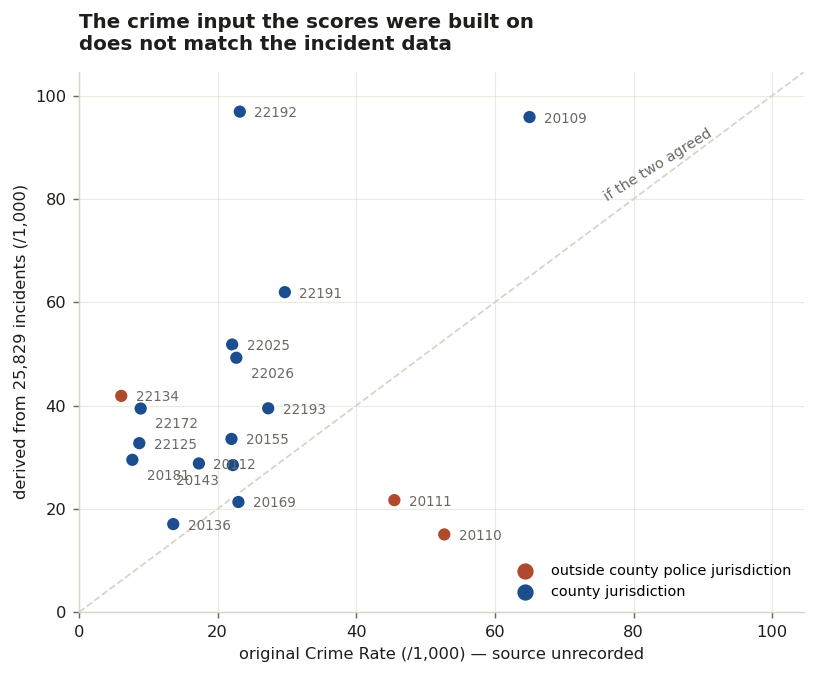

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 5.4))
col = np.where(ind.OutsideJurisdiction, WARN, ACCENT)
ax.scatter(ind.CrimeRateOriginal, ind.CrimeRate, s=64, c=col, zorder=3,
           edgecolor="white", linewidth=1.2)
lim = max(ind.CrimeRate.max(), ind.CrimeRateOriginal.max()) * 1.08
# Labels are placed one at a time; each takes the first candidate offset that
# does not land on a box already drawn.
CAND = [(8, -3), (8, 5), (8, -11), (-8, -3), (-8, 5), (-8, -11)]
SPAN, LINE = 9.0, 3.4          # data units a label roughly occupies
placed = []
for _, r in ind.sort_values("CrimeRate", ascending=False).iterrows():
    x, y = r.CrimeRateOriginal, r.CrimeRate
    for dx, dy in CAND:
        cx = x + (SPAN / 2 + 1) * (1 if dx > 0 else -1)
        cy = y + dy * lim / 400
        if not any(abs(cx - px) < SPAN and abs(cy - py) < LINE for px, py in placed):
            break
    ax.annotate(r.ZIP, (x, y), fontsize=7.5, color=MUTED,
                ha="left" if dx > 0 else "right",
                xytext=(dx, dy), textcoords="offset points")
    placed.append((cx, cy))
ax.plot([0, lim], [0, lim], color=RULE, lw=1, ls="--", zorder=1)
ax.annotate("if the two agreed", (lim * 0.72, lim * 0.76), fontsize=8, color=MUTED,
            rotation=32)
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel("original Crime Rate (/1,000) — source unrecorded")
ax.set_ylabel("derived from 25,829 incidents (/1,000)")
ax.set_title("The crime input the scores were built on\ndoes not match the incident data",
             fontsize=11)
ax.scatter([], [], c=WARN, s=64, label="outside county police jurisdiction")
ax.scatter([], [], c=ACCENT, s=64, label="county jurisdiction")
ax.legend(loc="lower right", fontsize=8)
ax.grid(axis="both", alpha=.5)
save(fig, "figure1_crime_rate_discrepancy"); plt.show()

## 2. The six indicators

Normalised to 0–1 with min–max scaling, which is what the original did and is worth
being honest about: with **n = 17**, the best and worst area are pinned to exactly
1.0 and 0.0 on every indicator by construction. The spread of the final score is
therefore partly an artefact of the scaling, not a finding about the county.

In [6]:
INDICATORS = ["CrimeRate", "Income", "Education", "Housing", "Unemployment", "Density"]

def minmax(s, invert=False):
    v = (s - s.min()) / (s.max() - s.min())
    return 1 - v if invert else v

# Direction of each indicator: True means "a larger raw value is worse".
# Crime and unemployment are not arguable. The other two are — see below.
DIRECTION = {"CrimeRate": True, "Unemployment": True, "Income": False,
             "Education": False, "Housing": True, "Density": False}

def score_frame(d, direction=DIRECTION):
    s = d[["ZIP", "Population", "OutsideJurisdiction"]].copy()
    for k in INDICATORS:
        s[k.replace("Rate", "") + "Score" if k == "CrimeRate" else k + "Score"] = \
            minmax(d[k], invert=direction[k])
    return s

scored = score_frame(ind)
SCORE_COLS = ["CrimeScore", "IncomeScore", "EducationScore", "HousingScore",
              "UnemploymentScore", "DensityScore"]
scored[SCORE_COLS] = scored[SCORE_COLS].round(4)
scored.head(3)

,ZIP,Population,OutsideJurisdiction,CrimeScore,IncomeScore,EducationScore,HousingScore,UnemploymentScore,DensityScore
0,20109,43849.0,False,0.0128,0.1611,0.1458,0.7781,0.5773,0.2495
1,20110,49120.0,True,1.0000,0.4022,0.0982,0.7354,0.6907,0.6837
2,20111,38883.0,True,0.9189,0.3208,0.0000,0.7301,0.5670,0.5329


### Two of the six directions are a judgement call, and the original code and its
### own chart labels disagreed about one of them

**Housing.** The original computed `HousingScore = minmax(Housing)` — *higher price,
higher score* — while the chart plotting it was titled *"Housing Affordability Score
(Higher = Cheaper)"*. The label described the opposite of the arithmetic. Here the
indicator is inverted, so a cheaper area scores better, which matches the stated
intent and keeps it from double-counting income. The opposite reading is defensible
— an expensive area is expensive because people want to live there — so §5 measures
what happens under it.

**Density.** The original did not invert it and the README said it did. Denser areas
in a commuter county are closer to jobs and amenities; they are also more congested.
Left un-inverted here, and also tested in §5.

wrote images/figure2_indicators.png


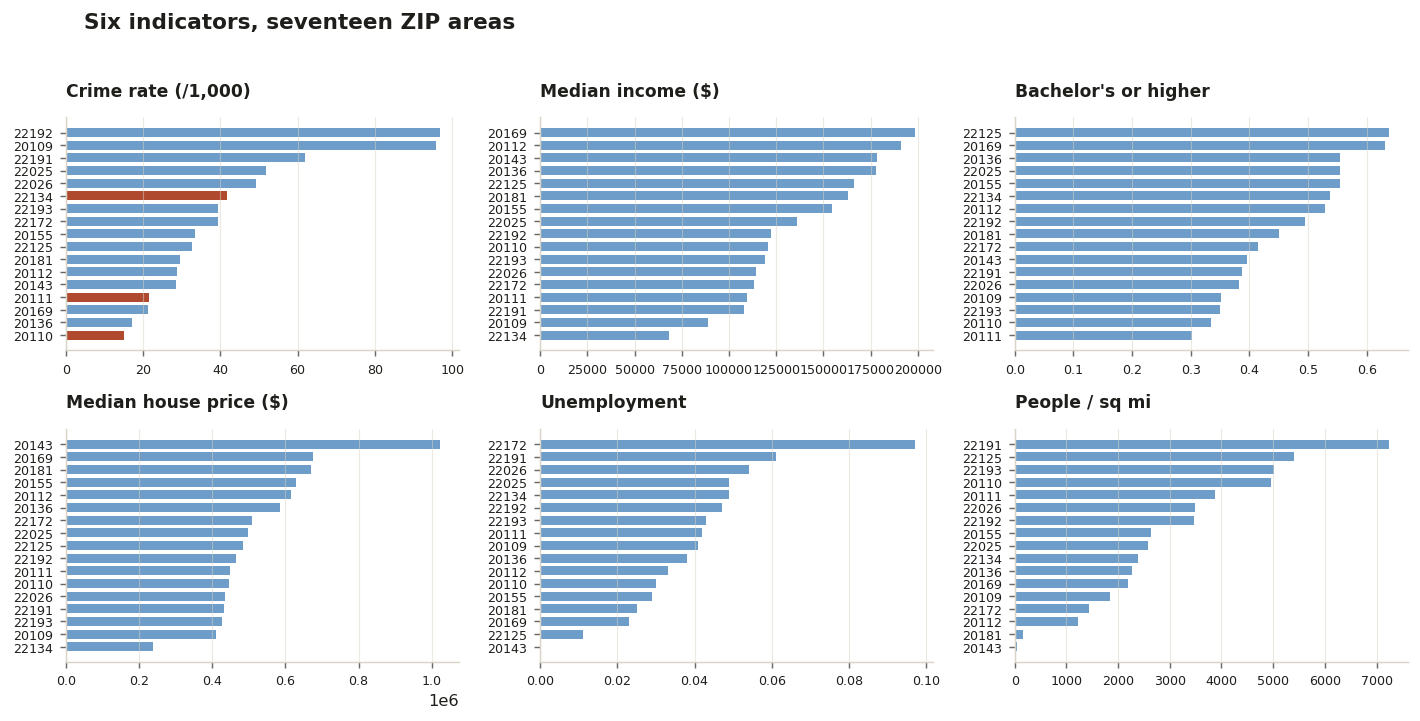

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(11, 5.6))
titles = {"CrimeRate": "Crime rate (/1,000)", "Income": "Median income ($)",
          "Education": "Bachelor's or higher", "Housing": "Median house price ($)",
          "Unemployment": "Unemployment", "Density": "People / sq mi"}
for ax, k in zip(axes.ravel(), INDICATORS):
    v = ind.sort_values(k)
    c = np.where(v.OutsideJurisdiction & (k == "CrimeRate"), WARN, COOL)
    ax.barh(v.ZIP, v[k], color=c, height=.72)
    ax.set_title(titles[k], fontsize=9.5)
    ax.tick_params(labelsize=7)
    ax.grid(axis="x", alpha=.5)
fig.suptitle("Six indicators, seventeen ZIP areas", x=.062, ha="left",
             fontsize=12, fontweight="bold", color=INK)
fig.tight_layout(rect=(0, 0, 1, .96))
save(fig, "figure2_indicators"); plt.show()

wrote images/figure3_correlation.png


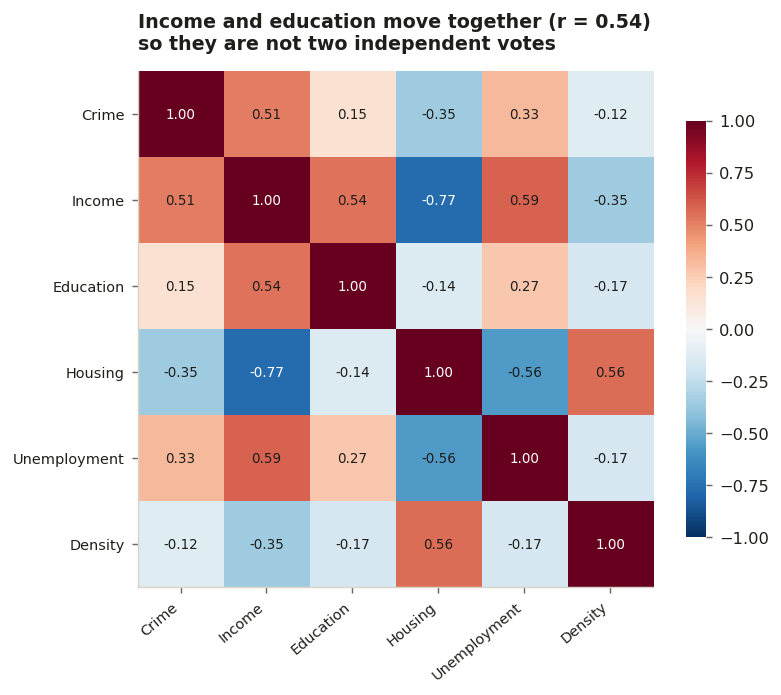

In [8]:
fig, ax = plt.subplots(figsize=(6.4, 5.2))
corr = scored[SCORE_COLS].corr()
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
lbl = [c.replace("Score", "") for c in SCORE_COLS]
ax.set_xticks(range(6), lbl, rotation=40, ha="right", fontsize=8)
ax.set_yticks(range(6), lbl, fontsize=8)
for i in range(6):
    for j in range(6):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.5,
                color="white" if abs(v) > .6 else INK)
ax.set_title("Income and education move together (r = %.2f)\nso they are not two independent votes"
             % corr.loc["IncomeScore", "EducationScore"], fontsize=10.5)
fig.colorbar(im, ax=ax, shrink=.8).outline.set_visible(False)
save(fig, "figure3_correlation"); plt.show()

## 3. The composite

The weights are the ones the original project chose. They are a judgement, not a
result — §4 is about how much they matter.

In [9]:
WEIGHTS = {"CrimeScore": 0.30, "IncomeScore": 0.20, "EducationScore": 0.20,
           "HousingScore": 0.10, "UnemploymentScore": 0.10, "DensityScore": 0.10}
assert abs(sum(WEIGHTS.values()) - 1) < 1e-9

def composite(s, weights=WEIGHTS):
    return sum(s[k] * w for k, w in weights.items()) * 100

scored["FinalScore"] = composite(scored)
scored = scored.sort_values("FinalScore", ascending=False).reset_index(drop=True)
scored["Rank"] = scored.index + 1
scored.to_csv(OUT / "zip_scores.csv", index=False)
scored[["Rank", "ZIP", "FinalScore"] + SCORE_COLS + ["OutsideJurisdiction"]].round(3)

,Rank,ZIP,FinalScore,CrimeScore,IncomeScore,EducationScore,HousingScore,UnemploymentScore,DensityScore,OutsideJurisdiction
0,1,20169,82.315,0.923,1.000,0.979,0.441,0.763,0.300,False
1,2,22125,81.744,0.784,0.754,1.000,0.684,0.887,0.743,False
2,3,20136,75.964,0.976,0.845,0.753,0.557,0.608,0.309,False
3,4,20112,70.721,0.832,0.945,0.673,0.518,0.660,0.163,False
4,5,20155,67.119,0.774,0.664,0.750,0.500,0.701,0.361,False
5,6,20110,61.106,1.000,0.402,0.098,0.735,0.691,0.684,True
6,7,20181,60.209,0.824,0.729,0.444,0.447,0.742,0.016,False
7,8,20143,57.518,0.836,0.845,0.277,0.000,1.000,0.000,False
8,9,22025,57.167,0.551,0.522,0.753,0.669,0.495,0.352,False
9,10,22134,52.351,0.672,0.000,0.699,1.000,0.495,0.325,True


wrote images/figure4_ranking.png


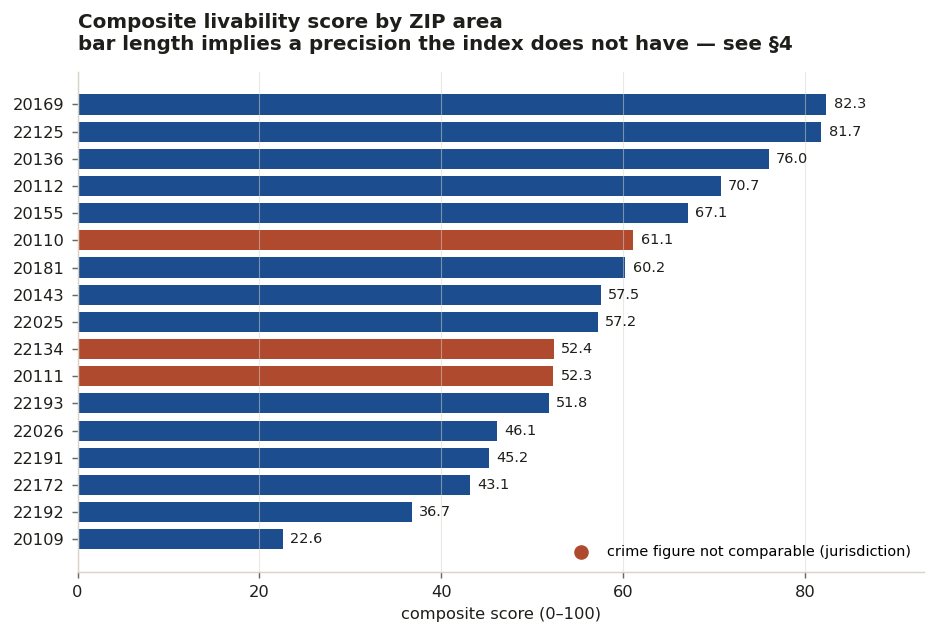

In [10]:
fig, ax = plt.subplots(figsize=(8.4, 5))
v = scored.sort_values("FinalScore")
col = np.where(v.OutsideJurisdiction, WARN, ACCENT)
ax.barh(v.ZIP, v.FinalScore, color=col, height=.74)
for _, r in v.iterrows():
    ax.text(r.FinalScore + .8, r.ZIP, f"{r.FinalScore:.1f}", va="center",
            fontsize=8, color=INK)
ax.set_xlabel("composite score (0–100)")
ax.set_xlim(0, max(v.FinalScore) * 1.13)
ax.set_title("Composite livability score by ZIP area\nbar length implies a precision the index does not have — see §4",
             fontsize=11)
ax.scatter([], [], c=WARN, s=50, label="crime figure not comparable (jurisdiction)")
ax.legend(loc="lower right", fontsize=8)
ax.grid(axis="x", alpha=.5)
save(fig, "figure4_ranking"); plt.show()

wrote images/figure5_map.png


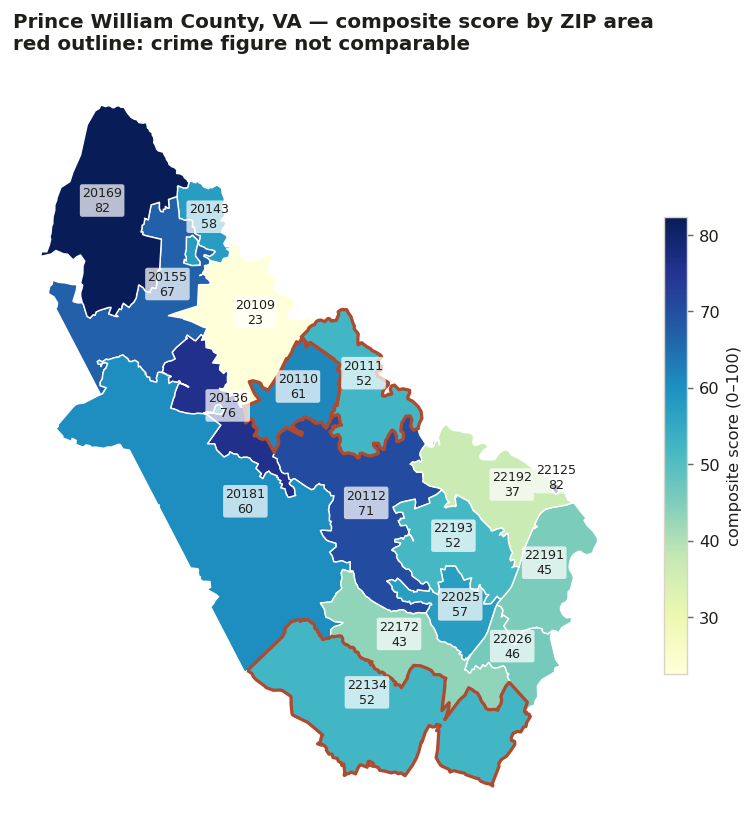

In [11]:
m = shapes.merge(scored, on="ZIP", how="left")
fig, ax = plt.subplots(figsize=(7.6, 7.6))
m.plot(column="FinalScore", cmap="YlGnBu", legend=True, edgecolor="white",
       linewidth=.8, ax=ax,
       legend_kwds={"shrink": .6, "label": "composite score (0–100)"})
m[m.OutsideJurisdiction].boundary.plot(ax=ax, color=WARN, linewidth=1.8)
for _, r in m.iterrows():
    c = r.geometry.representative_point()
    ax.annotate(f"{r.ZIP}\n{r.FinalScore:.0f}", (c.x, c.y), ha="center",
                fontsize=7, color=INK,
                bbox=dict(boxstyle="round,pad=.18", fc="white", ec="none", alpha=.72))
ax.set_axis_off()
ax.set_title("Prince William County, VA — composite score by ZIP area\n"
             "red outline: crime figure not comparable", fontsize=11)
save(fig, "figure5_map"); plt.show()

## 4. How much of this ranking is the weights?

The weights above were chosen, not derived. The test: draw 10,000 weight vectors
uniformly over the simplex — every possible way of splitting 100% across the six
indicators is equally likely — and re-rank each time.

An area whose rank barely moves is a real finding. An area whose rank swings across
half the table is an artefact of one particular choice.

In [12]:
rng = np.random.default_rng(7)
N = 10_000
draws = rng.dirichlet(np.ones(6), size=N)          # uniform over the simplex
S = scored.set_index("ZIP")[SCORE_COLS].to_numpy()  # 17 x 6

# 17 x N matrix of scores, then rank within each column.
allscores = S @ draws.T * 100
ranks = (-allscores).argsort(axis=0).argsort(axis=0) + 1

zips = scored.ZIP.to_numpy()
sens = pd.DataFrame({
    "ZIP": zips,
    "RankBase": scored.Rank.to_numpy(),
    "RankMedian": np.median(ranks, axis=1),
    "Rank5": np.percentile(ranks, 5, axis=1),
    "Rank95": np.percentile(ranks, 95, axis=1),
    "ShareTop5": (ranks <= 5).mean(axis=1),
    "ShareBottom5": (ranks >= 13).mean(axis=1),
}).sort_values("RankMedian")
sens["RankSwing"] = sens.Rank95 - sens.Rank5
sens.to_csv(OUT / "weight_sensitivity.csv", index=False)
sens.round(2)

,ZIP,RankBase,RankMedian,Rank5,Rank95,ShareTop5,ShareBottom5,RankSwing
1,22125,2,1.0,1.0,3.0,1.00,0.00,2.0
0,20169,1,2.0,1.0,8.0,0.89,0.01,7.0
2,20136,3,4.0,2.0,8.0,0.81,0.00,6.0
3,20112,4,5.0,3.0,13.0,0.51,0.06,10.0
4,20155,5,6.0,4.0,11.0,0.46,0.01,7.0
5,20110,6,6.0,2.0,11.0,0.46,0.03,9.0
6,20181,7,9.0,6.0,15.0,0.01,0.29,9.0
8,22025,9,9.0,5.0,13.0,0.06,0.05,8.0
11,22193,12,10.0,4.0,13.0,0.16,0.06,9.0
9,22134,10,10.0,2.0,16.0,0.19,0.27,14.0


wrote images/figure6_weight_sensitivity.png


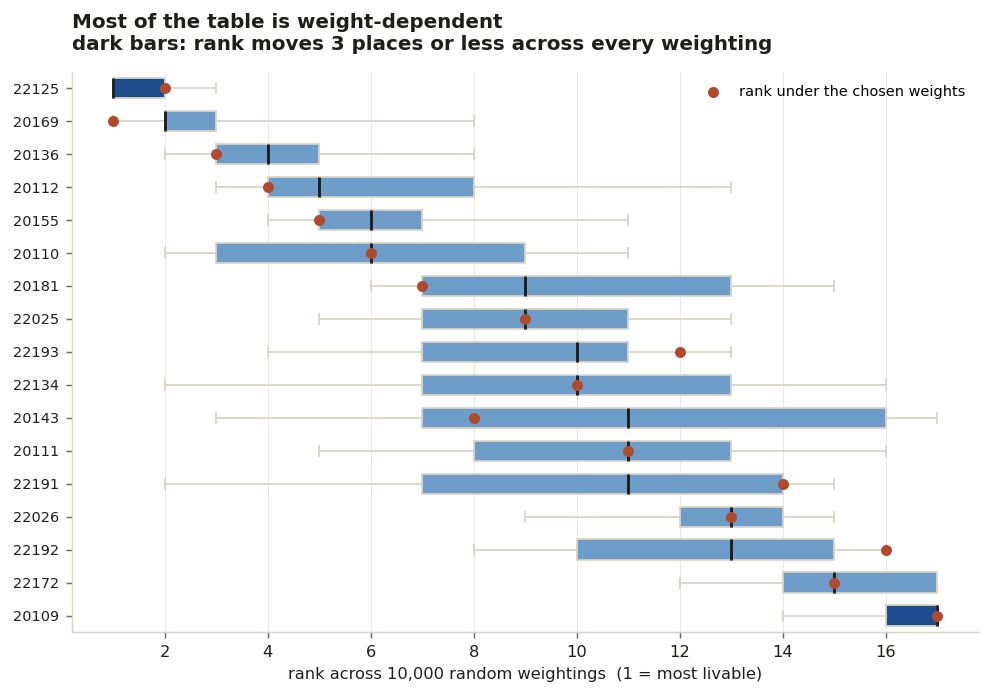

In [13]:
order = sens.sort_values("RankMedian").ZIP.tolist()
pos = {z: i for i, z in enumerate(zips)}
fig, ax = plt.subplots(figsize=(9, 5.6))
data = [ranks[pos[z]] for z in order]
bp = ax.boxplot(data, vert=False, widths=.62, patch_artist=True, whis=(5, 95),
                showfliers=False,
                medianprops=dict(color=INK, lw=1.6),
                boxprops=dict(facecolor=COOL, edgecolor=RULE),
                whiskerprops=dict(color=RULE), capprops=dict(color=RULE))
for patch, z in zip(bp["boxes"], order):
    if sens.set_index("ZIP").loc[z, "RankSwing"] <= 3:
        patch.set_facecolor(ACCENT)
base = scored.set_index("ZIP").Rank
ax.scatter([base[z] for z in order], range(1, len(order) + 1), color=WARN, s=26,
           zorder=5, label="rank under the chosen weights")
ax.set_yticks(range(1, len(order) + 1), order, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("rank across 10,000 random weightings  (1 = most livable)")
ax.set_title("Most of the table is weight-dependent\n"
             "dark bars: rank moves 3 places or less across every weighting",
             fontsize=11)
ax.legend(loc="upper right", fontsize=8)
ax.grid(axis="x", alpha=.5)
save(fig, "figure6_weight_sensitivity"); plt.show()

In [14]:
stable = sens[sens.RankSwing <= 3]
locked_top = sens[sens.ShareTop5 > .9]
locked_bot = sens[sens.ShareBottom5 > .9]
print(f"ZIPs whose rank moves <= 3 places under any weighting: "
      f"{len(stable)} of {len(sens)}")
print(f"  top-5 under >90% of weightings:    {', '.join(locked_top.ZIP) or 'none'}")
print(f"  bottom-5 under >90% of weightings: {', '.join(locked_bot.ZIP) or 'none'}")
print(f"\nmedian rank swing (5th to 95th pct): {sens.RankSwing.median():.0f} places "
      f"out of {len(sens)}")

ZIPs whose rank moves <= 3 places under any weighting: 2 of 17
  top-5 under >90% of weightings:    22125
  bottom-5 under >90% of weightings: 22172, 20109

median rank swing (5th to 95th pct): 8 places out of 17


## 5. And how much of it is the direction choices?

Housing and density were the two arguable directions. Four combinations, base weights.

In [15]:
combos = {}
for h in (True, False):
    for d in (True, False):
        direction = dict(DIRECTION, Housing=h, Density=d)
        s = score_frame(ind, direction)
        s["FinalScore"] = composite(s)
        name = ("cheaper=better" if h else "pricier=better") + " / " + \
               ("sparser=better" if d else "denser=better")
        combos[name] = s.set_index("ZIP").FinalScore.rank(ascending=False)

dirs = pd.DataFrame(combos)
dirs["spread"] = dirs.max(axis=1) - dirs.min(axis=1)
dirs = dirs.sort_values(list(combos)[0])
print(f"largest rank spread caused purely by the two direction choices: "
      f"{dirs.spread.max():.0f} places")
dirs.astype(int)

largest rank spread caused purely by the two direction choices: 5 places


,cheaper=better / sparser=better,cheaper=better / denser=better,pricier=better / sparser=better,pricier=better / denser=better,spread
ZIP,,,,,
20169,1,1,1,1,0
20136,2,3,2,3,1
20112,3,4,4,4,1
22125,4,2,5,2,3
20155,5,5,7,6,2
20181,6,7,6,7,1
20143,7,8,3,5,5
22025,8,9,8,9,1
20110,9,6,9,8,3


## 6. What actually survives

Everything below is stated at the strength the analysis supports, which is lower
than a ranked table of seventeen numbers appears to promise.

In [16]:
top = scored[~scored.OutsideJurisdiction].head(3)
bot = scored[~scored.OutsideJurisdiction].tail(3)
summary = {
    "areas scored": len(scored),
    "incidents behind the crime indicator": int(ind.Incidents.sum()),
    "rank agreement with the original crime figure (spearman)": round(spearman, 3),
    "ZIPs with a stable rank (<=3 places, any weighting)": int((sens.RankSwing <= 3).sum()),
    "median rank swing across weightings": int(sens.RankSwing.median()),
    "rank spread from the two direction choices alone": int(dirs.spread.max()),
    "areas excluded from comparison (jurisdiction)": int(ind.OutsideJurisdiction.sum()),
}
(Path("outputs") / "summary.json").write_text(json.dumps(summary, indent=2))
for k, v in summary.items():
    print(f"  {v!s:>8}   {k}")

        17   areas scored
     25770   incidents behind the crime indicator
     0.115   rank agreement with the original crime figure (spearman)
         2   ZIPs with a stable rank (<=3 places, any weighting)
         8   median rank swing across weightings
         5   rank spread from the two direction choices alone
         3   areas excluded from comparison (jurisdiction)


**The ranking is not a ranking.** Across every possible weighting of the six
indicators, the median ZIP area moves about half the length of the table. Only a
handful hold their position, and those are the ones worth naming — the rest of the
order is a restatement of the weights that produced it.

**The crime indicator is the weakest link and the heaviest.** It carries 0.30 of the
composite, it had to be rebuilt from source because the original export was
truncated at an API limit, and in three of seventeen areas it measures which police
department files the paperwork rather than how safe the place is.

**Two areas are too small to rate.** Occoquan (917 residents) and Catharpin (1,124)
produce crime rates from a few dozen incidents; their Poisson intervals overlap most
of the table.

**What the index is good for:** separating the clearly-safer, higher-income north and
west of the county from the denser Woodbridge corridor along I-95. It supports
"these few areas differ from those few" — not a ranked list of seventeen.

### If this were taken further

- Replace min–max with a percentile or z-score normalisation, so one extreme area
  stops defining the whole scale.
- Weight by something other than judgement — principal components, or a survey of
  what residents actually say they weigh.
- Get the two independent cities' incident data from their own departments so all
  seventeen areas are measured the same way.